# Representing Data and Engineering Features

**Buku:** *Introduction to Machine Learning with Python: A Guide for Data Scientists*  
**Chapter:** Representing Data and Engineering Features  
**Bahasa notebook:** Indonesia  

Notebook ini berisi rangkuman, penjelasan teori, tabel pembanding, contoh kode, visualisasi, dan analisis hasil dari materi representasi data dan feature engineering. Seluruh penjelasan ditulis ulang secara orisinal agar sesuai dengan prinsip academic integrity.

## Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, pembaca diharapkan mampu memahami bahwa performa model machine learning tidak hanya ditentukan oleh algoritma, tetapi juga oleh cara data direpresentasikan. Pada chapter ini, fokus utama berada pada bagaimana fitur mentah diubah menjadi bentuk yang lebih informatif dan lebih mudah dipelajari oleh model.

Tujuan pembelajaran dalam notebook ini meliputi:

| Tujuan | Penjelasan |
|---|---|
| Memahami feature engineering | Mengetahui mengapa transformasi fitur dapat memengaruhi performa model |
| Membedakan fitur kontinu dan kategorikal | Mengetahui kapan sebuah fitur diperlakukan sebagai angka dan kapan sebagai kategori |
| Menerapkan one-hot encoding | Mengubah fitur kategorikal menjadi format numerik |
| Memahami numeric categories | Menentukan apakah angka pada data merupakan nilai kontinu atau hanya label |
| Menerapkan binning | Mengubah nilai kontinu menjadi interval |
| Membuat interaction features | Menggabungkan beberapa fitur untuk menangkap hubungan antarvariabel |
| Membuat polynomial features | Menambahkan pangkat fitur untuk membantu model linear menangkap pola non-linear |
| Menerapkan nonlinear transformations | Menggunakan log transformation untuk data yang distribusinya tidak seimbang |
| Membandingkan dampak transformasi | Melihat bahwa transformasi tertentu dapat membantu model tertentu, tetapi tidak selalu membantu semua model |

## Persiapan Library

Bagian ini memuat library yang digunakan dalam notebook. Dataset yang dipakai dibuat secara sintetis atau menggunakan dataset bawaan `scikit-learn`, sehingga notebook tetap dapat dijalankan tanpa perlu mengunduh file eksternal.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score

np.random.seed(42)
pd.set_option("display.max_columns", 100)

## Ringkasan Umum Chapter

Chapter ini membahas **feature engineering**, yaitu proses mengubah data mentah menjadi representasi fitur yang lebih sesuai untuk algoritma machine learning. Pada praktik nyata, data jarang langsung tersedia dalam bentuk matriks numerik yang rapi. Data sering memiliki nilai kategorikal, satuan yang berbeda, distribusi yang sangat miring, atau hubungan antarvariabel yang tidak terlihat secara langsung.

Inti dari chapter ini adalah bahwa representasi data dapat sangat memengaruhi performa model. Dua model yang sama dapat menghasilkan performa berbeda apabila fitur yang diberikan berbeda. Bahkan, dalam beberapa kasus, feature engineering yang tepat dapat memberikan peningkatan performa yang lebih besar dibandingkan mengganti algoritma.

| Konsep | Fokus Pembahasan | Dampak terhadap Model |
|---|---|---|
| Categorical variables | Mengubah kategori menjadi angka | Membuat data dapat digunakan model |
| One-hot encoding | Membuat kolom biner untuk setiap kategori | Menghindari urutan palsu pada kategori |
| Numeric categories | Membedakan angka sebagai nilai vs label | Mencegah model salah memahami makna angka |
| Binning | Mengubah nilai kontinu menjadi interval | Membantu model linear menangkap pola non-linear |
| Interaction features | Menggabungkan dua fitur atau lebih | Menangkap hubungan antar fitur |
| Polynomial features | Menambahkan fitur pangkat | Membantu model linear membentuk kurva |
| Nonlinear transformations | Mengubah skala/distribusi fitur | Membantu model yang sensitif terhadap distribusi |

## Categorical Variables

Variabel kategorikal adalah fitur yang nilainya berbentuk kategori atau label. Berbeda dengan fitur kontinu, nilai kategorikal tidak memiliki jarak matematis yang jelas. Misalnya, kategori `Private`, `Government`, dan `Self-employed` pada fitur pekerjaan tidak dapat dibandingkan menggunakan operasi matematika seperti lebih besar atau lebih kecil.

Masalahnya, sebagian besar algoritma machine learning membutuhkan input numerik. Logistic Regression, Linear Regression, SVM, dan banyak model lain melakukan operasi matematika terhadap fitur. Oleh karena itu, nilai seperti `Bachelors`, `Masters`, atau `Doctorate` perlu dikonversi menjadi representasi numerik yang tetap menjaga makna kategorinya.

| Jenis Fitur | Contoh | Cara Memahami |
|---|---|---|
| Kontinu | Umur, jam kerja, pendapatan | Memiliki skala angka dan jarak bermakna |
| Kategorikal nominal | Warna, pekerjaan, jenis kelamin | Tidak memiliki urutan alami |
| Kategorikal ordinal | Tingkat pendidikan, rating kepuasan | Memiliki urutan, tetapi jaraknya belum tentu sama |

Kesalahan umum pada data kategorikal adalah langsung mengubah kategori menjadi angka seperti `0`, `1`, dan `2`. Cara ini dapat membuat model menganggap kategori memiliki urutan atau jarak tertentu, padahal belum tentu benar.

## Contoh Dataset Kategorikal

Contoh berikut menggunakan dataset kecil berisi informasi pekerja. Dataset ini dibuat sederhana agar fokus pembelajaran berada pada cara representasi fitur, bukan pada kompleksitas dataset.

In [54]:
data = pd.DataFrame({
    "age": [39, 50, 38, 53, 28, 37, 49, 52, 31, 42],
    "workclass": ["State-gov", "Self-emp", "Private", "Private", "Private",
                  "Private", "Private", "Self-emp", "Private", "Private"],
    "education": ["Bachelors", "Bachelors", "HS-grad", "11th", "Bachelors",
                  "Masters", "9th", "HS-grad", "Masters", "Bachelors"],
    "gender": ["Male", "Male", "Male", "Male", "Female",
               "Female", "Female", "Male", "Female", "Male"],
    "hours_per_week": [40, 13, 40, 40, 40, 40, 16, 45, 50, 40],
    "income": ["<=50K", "<=50K", "<=50K", "<=50K", "<=50K",
               "<=50K", "<=50K", ">50K", ">50K", ">50K"]
})

data

,age,workclass,education,gender,hours_per_week,income
0,39,State-gov,Bachelors,Male,40,<=50K
1,50,Self-emp,Bachelors,Male,13,<=50K
2,38,Private,HS-grad,Male,40,<=50K
3,53,Private,11th,Male,40,<=50K
4,28,Private,Bachelors,Female,40,<=50K
5,37,Private,Masters,Female,40,<=50K
6,49,Private,9th,Female,16,<=50K
7,52,Self-emp,HS-grad,Male,45,>50K
8,31,Private,Masters,Female,50,>50K
9,42,Private,Bachelors,Male,40,>50K


## Pemeriksaan Nilai Kategorikal

Sebelum encoding dilakukan, isi kolom kategorikal perlu diperiksa. Tujuannya adalah memastikan tidak ada perbedaan penulisan seperti `Male`, `male`, atau `MALE` yang sebenarnya merepresentasikan kategori sama. Pada dataset dunia nyata, kesalahan seperti ini sering terjadi karena data diinput oleh manusia.

Fungsi `value_counts()` dapat digunakan untuk melihat kategori unik dan frekuensinya.

In [55]:
for col in ["workclass", "education", "gender", "income"]:
    print(f"\nKolom: {col}")
    print(data[col].value_counts())


Kolom: workclass
workclass
Private      7
Self-emp     2
State-gov    1
Name: count, dtype: int64

Kolom: education
education
Bachelors    4
HS-grad      2
Masters      2
11th         1
9th          1
Name: count, dtype: int64

Kolom: gender
gender
Male      6
Female    4
Name: count, dtype: int64

Kolom: income
income
<=50K    7
>50K     3
Name: count, dtype: int64


## One-Hot Encoding

One-Hot Encoding adalah teknik yang mengubah setiap kategori menjadi kolom biner. Jika sebuah data termasuk dalam kategori tertentu, kolom tersebut bernilai `1`; jika tidak, bernilai `0`.

Teknik ini cocok untuk kategori nominal karena tidak membuat urutan palsu antar kategori. Misalnya, `Private` tidak dianggap lebih besar daripada `State-gov`, dan `Bachelors` tidak otomatis dianggap dua kali lebih besar daripada `HS-grad`.

| Kelebihan | Penjelasan |
|---|---|
| Tidak membuat urutan palsu | Setiap kategori direpresentasikan sebagai kolom terpisah |
| Mudah dipahami | Output berupa nilai 0 dan 1 |
| Didukung banyak library | Dapat dilakukan dengan `pandas.get_dummies()` atau `OneHotEncoder` |
| Cocok untuk model linear | Model dapat memberi bobot berbeda pada tiap kategori |

| Kekurangan | Penjelasan |
|---|---|
| Dimensi bertambah | Semakin banyak kategori, semakin banyak kolom baru |
| Bisa boros memori | Terutama jika kategori sangat banyak |
| Perlu konsistensi train-test | Kolom hasil encoding pada data training dan testing harus sama |

In [56]:
data_encoded = pd.get_dummies(data, columns=["workclass", "education", "gender"], drop_first=False)

data_encoded

,age,hours_per_week,income,workclass_Private,workclass_Self-emp,workclass_State-gov,education_11th,education_9th,education_Bachelors,education_HS-grad,education_Masters,gender_Female,gender_Male
0,39,40,<=50K,False,False,True,False,False,True,False,False,False,True
1,50,13,<=50K,False,True,False,False,False,True,False,False,False,True
2,38,40,<=50K,True,False,False,False,False,False,True,False,False,True
3,53,40,<=50K,True,False,False,True,False,False,False,False,False,True
4,28,40,<=50K,True,False,False,False,False,True,False,False,True,False
5,37,40,<=50K,True,False,False,False,False,False,False,True,True,False
6,49,16,<=50K,True,False,False,False,True,False,False,False,True,False
7,52,45,>50K,False,True,False,False,False,False,True,False,False,True
8,31,50,>50K,True,False,False,False,False,False,False,True,True,False
9,42,40,>50K,True,False,False,False,False,True,False,False,False,True


## Analisis One-Hot Encoding

Setelah one-hot encoding, kolom kategorikal berubah menjadi beberapa kolom numerik. Contohnya, `gender` berubah menjadi `gender_Female` dan `gender_Male`. Dengan representasi ini, algoritma machine learning dapat memproses data karena seluruh fitur sudah berbentuk angka.

Namun, target `income` belum diubah menjadi angka. Untuk klasifikasi biner, target dapat diubah menjadi `0` dan `1`.

In [57]:
X = data_encoded.drop(columns=["income"])
y = (data_encoded["income"] == ">50K").astype(int)

print("Bentuk X:", X.shape)
print("Bentuk y:", y.shape)
display(X.head())
display(y.head())

Bentuk X: (10, 12)
Bentuk y: (10,)


,age,hours_per_week,workclass_Private,workclass_Self-emp,workclass_State-gov,education_11th,education_9th,education_Bachelors,education_HS-grad,education_Masters,gender_Female,gender_Male
0,39,40,False,False,True,False,False,True,False,False,False,True
1,50,13,False,True,False,False,False,True,False,False,False,True
2,38,40,True,False,False,False,False,False,True,False,False,True
3,53,40,True,False,False,True,False,False,False,False,False,True
4,28,40,True,False,False,False,False,True,False,False,True,False


0    0
1    0
2    0
3    0
4    0
Name: income, dtype: int64

## One-Hot Encoding dalam Pipeline

Pada praktik machine learning yang lebih rapi, encoding sebaiknya diletakkan di dalam pipeline. Pipeline membantu memastikan proses preprocessing pada data training dan data testing dilakukan secara konsisten.

Pada contoh berikut, fitur numerik dibiarkan apa adanya, sedangkan fitur kategorikal diubah menggunakan `OneHotEncoder`.

In [58]:
X_raw = data.drop(columns=["income"])
y_raw = (data["income"] == ">50K").astype(int)

numeric_features = ["age", "hours_per_week"]
categorical_features = ["workclass", "education", "gender"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_raw, y_raw)
pred = model.predict(X_raw)

print("Akurasi pada data contoh:", accuracy_score(y_raw, pred))

Akurasi pada data contoh: 0.9


## Numeric Categories

Fitur numerik tidak selalu berarti fitur kontinu. Beberapa angka hanya digunakan sebagai kode kategori. Misalnya, `0 = Private`, `1 = Government`, dan `2 = Self-employed`. Jika angka ini diperlakukan sebagai nilai kontinu, model dapat salah memahami maknanya.

Perbedaan pentingnya adalah:

| Kondisi | Contoh | Perlakuan yang Tepat |
|---|---|---|
| Angka sebagai nilai kuantitatif | Umur 20, 30, 40 | Dapat diperlakukan sebagai numerik |
| Angka sebagai kode kategori | 0 = merah, 1 = biru, 2 = hijau | Sebaiknya di-one-hot encode |
| Angka sebagai ordinal | Rating 1 sampai 5 | Tergantung konteks dan model |

In [59]:
demo_df = pd.DataFrame({
    "Kode_Pekerjaan": [0, 1, 2, 1, 0],
    "Jam_Kerja": [40, 35, 45, 20, 50]
})

display(demo_df)

encoded_demo = pd.get_dummies(demo_df.astype({"Kode_Pekerjaan": str}), columns=["Kode_Pekerjaan"])
encoded_demo

,Kode_Pekerjaan,Jam_Kerja
0,0,40
1,1,35
2,2,45
3,1,20
4,0,50


,Jam_Kerja,Kode_Pekerjaan_0,Kode_Pekerjaan_1,Kode_Pekerjaan_2
0,40,True,False,False
1,35,False,True,False
2,45,False,False,True
3,20,False,True,False
4,50,True,False,False


## Analisis Numeric Categories

Pada contoh di atas, `Kode_Pekerjaan` adalah angka, tetapi maknanya adalah label kategori. Oleh karena itu, kolom tersebut dikonversi menjadi string terlebih dahulu sebelum dilakukan one-hot encoding.

Hal ini penting karena `pandas.get_dummies()` secara default hanya mengubah kolom bertipe objek/string atau kategori. Jika kolom angka tidak diubah tipenya, pandas dapat menganggapnya sebagai fitur numerik biasa.

## Binning dan Discretization

Binning atau discretization adalah proses mengubah fitur kontinu menjadi beberapa interval. Contohnya, umur dapat dibagi menjadi kategori `remaja`, `dewasa muda`, `dewasa`, dan `lansia`.

Teknik ini berguna ketika hubungan antara fitur dan target tidak linear. Model linear biasanya hanya dapat membentuk garis lurus terhadap fitur asli. Dengan binning, model linear dapat memiliki nilai prediksi berbeda untuk setiap interval.

| Sebelum Binning | Setelah Binning |
|---|---|
| 18 | Remaja |
| 25 | Dewasa muda |
| 40 | Dewasa |
| 65 | Lansia |

| Kelebihan | Kekurangan |
|---|---|
| Membantu model linear menangkap pola non-linear | Informasi detail dalam interval dapat hilang |
| Dapat mengurangi noise | Pemilihan batas bin dapat memengaruhi hasil |
| Mudah diinterpretasikan | Tidak selalu membantu model tree-based |

In [60]:
umur = np.array([17, 22, 27, 35, 44, 58, 70])
bins = [0, 20, 35, 60, 100]
labels = ["Remaja", "Dewasa Muda", "Dewasa", "Lansia"]

umur_binned = pd.cut(umur, bins=bins, labels=labels)

pd.DataFrame({
    "Umur": umur,
    "Kategori_Umur": umur_binned
})

,Umur,Kategori_Umur
0,17,Remaja
1,22,Dewasa Muda
2,27,Dewasa Muda
3,35,Dewasa Muda
4,44,Dewasa
5,58,Dewasa
6,70,Lansia


## Visualisasi Pengaruh Binning

Contoh berikut menggunakan data sintetis satu fitur. Kita akan membandingkan Linear Regression dan Decision Tree pada data asli, kemudian melihat bagaimana binning dapat mengubah representasi data.

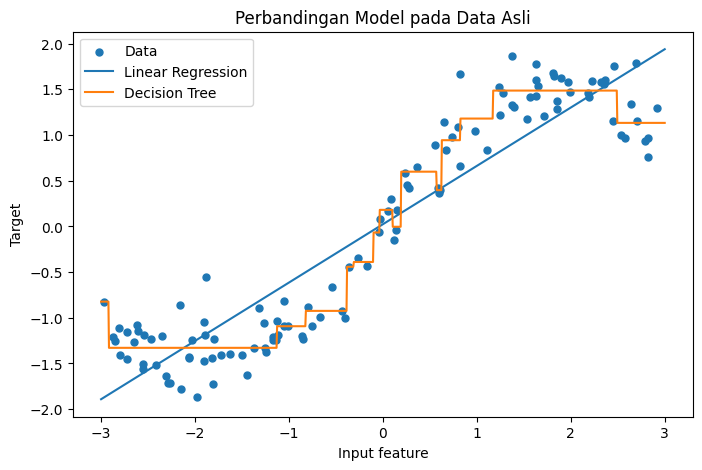

In [61]:
rng = np.random.RandomState(42)

X_wave = rng.uniform(-3, 3, size=(120, 1))
y_wave = np.sin(X_wave[:, 0]) + 0.3 * X_wave[:, 0] + rng.normal(scale=0.25, size=120)

line = np.linspace(-3, 3, 1000).reshape(-1, 1)

lin_reg = LinearRegression().fit(X_wave, y_wave)
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_wave, y_wave)

plt.figure(figsize=(8, 5))
plt.scatter(X_wave[:, 0], y_wave, s=25, label="Data")
plt.plot(line[:, 0], lin_reg.predict(line), label="Linear Regression")
plt.plot(line[:, 0], tree_reg.predict(line), label="Decision Tree")
plt.xlabel("Input feature")
plt.ylabel("Target")
plt.title("Perbandingan Model pada Data Asli")
plt.legend()
plt.show()

## Binning dengan One-Hot Encoding

Nilai kontinu pada `X_wave` dibagi menjadi beberapa bin. Setelah itu, hasil binning diubah menjadi bentuk one-hot agar dapat digunakan oleh model machine learning.

Pada representasi ini, satu fitur kontinu berubah menjadi beberapa fitur biner yang menunjukkan interval tempat data berada.

In [62]:
bin_edges = np.linspace(-3, 3, 11)
which_bin = np.digitize(X_wave[:, 0], bins=bin_edges)

encoder = OneHotEncoder(sparse_output=False)
X_binned = encoder.fit_transform(which_bin.reshape(-1, 1))

print("Bentuk data asli:", X_wave.shape)
print("Bentuk data setelah binning:", X_binned.shape)

pd.DataFrame(X_binned[:5], columns=[f"bin_{i}" for i in range(X_binned.shape[1])])

Bentuk data asli: (120, 1)
Bentuk data setelah binning: (120, 10)


,bin_0,bin_1,bin_2,bin_3,bin_4,bin_5,bin_6,bin_7,bin_8,bin_9
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# Kami menambahkan np.clip agar boundary value (3.0) di-clip ke bin indeks maksimal yang dikenali encoder (10)
line_bin = np.clip(np.digitize(line[:, 0], bins=bin_edges), 1, len(bin_edges) - 1)
line_binned = encoder.transform(line_bin.reshape(-1, 1))

## Analisis Binning

Setelah binning, Linear Regression tidak lagi hanya membentuk satu garis lurus. Model dapat membuat prediksi berbeda untuk setiap interval. Hal ini membuat model linear menjadi lebih fleksibel.

Namun, binning tidak selalu menguntungkan Decision Tree. Model tree-based sebenarnya sudah mampu membagi ruang fitur berdasarkan threshold tertentu. Karena itu, binning lebih sering bermanfaat untuk model linear dibandingkan model berbasis pohon.

| Model | Dampak Binning |
|---|---|
| Linear Regression | Biasanya membantu jika pola data non-linear |
| Logistic Regression | Dapat membantu pada fitur kontinu dengan hubungan non-linear |
| Decision Tree | Sering tidak terlalu diperlukan |
| Random Forest | Biasanya tidak perlu karena model sudah belajar split sendiri |

## Interaction Features

Interaction features adalah fitur baru yang dibuat dari kombinasi dua atau lebih fitur. Contoh paling sederhana adalah perkalian antara dua fitur.

Misalnya dalam data penjualan:

| Harga | Jumlah | Total |
|---|---|---|
| 100 | 2 | 200 |
| 200 | 3 | 600 |
| 300 | 4 | 1200 |

Fitur `Total` merupakan interaksi antara `Harga` dan `Jumlah`. Dalam banyak kasus, target tidak hanya dipengaruhi oleh masing-masing fitur secara terpisah, tetapi juga oleh kombinasi antarfitur.

In [64]:
sales = pd.DataFrame({
    "Harga": [100, 200, 300, 150, 250],
    "Jumlah": [2, 3, 4, 5, 1]
})

sales["Total_Interaksi"] = sales["Harga"] * sales["Jumlah"]
sales

,Harga,Jumlah,Total_Interaksi
0,100,2,200
1,200,3,600
2,300,4,1200
3,150,5,750
4,250,1,250


## Interaction Features pada Data Binning

Pada contoh binning sebelumnya, model linear hanya belajar nilai rata-rata untuk setiap bin. Agar model dapat memiliki kemiringan yang berbeda pada setiap bin, kita dapat menggabungkan fitur binning dengan fitur asli.

Fitur interaction dibuat dengan mengalikan indikator bin dengan nilai asli. Dengan begitu, model dapat mempelajari pola yang berbeda pada tiap interval.

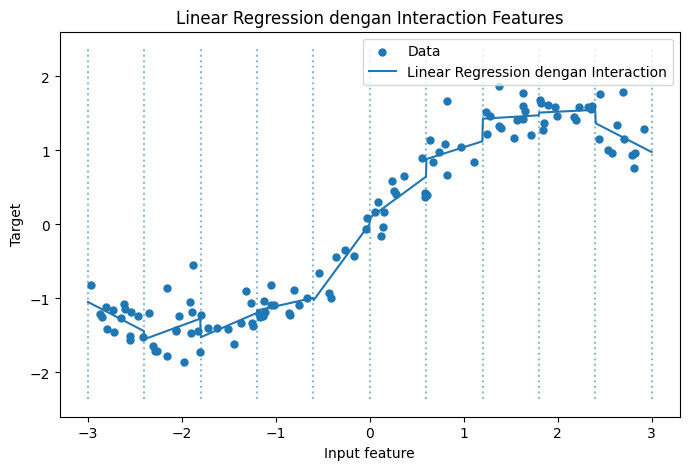

Bentuk data setelah interaction: (120, 20)


In [65]:
X_interaction = np.hstack([X_binned, X_wave * X_binned])
line_interaction = np.hstack([line_binned, line * line_binned])

lin_reg_interaction = LinearRegression().fit(X_interaction, y_wave)

plt.figure(figsize=(8, 5))
plt.scatter(X_wave[:, 0], y_wave, s=25, label="Data")
plt.plot(line[:, 0], lin_reg_interaction.predict(line_interaction), label="Linear Regression dengan Interaction")
plt.vlines(bin_edges, ymin=y_wave.min()-0.5, ymax=y_wave.max()+0.5, linestyles="dotted", alpha=0.5)
plt.xlabel("Input feature")
plt.ylabel("Target")
plt.title("Linear Regression dengan Interaction Features")
plt.legend()
plt.show()

print("Bentuk data setelah interaction:", X_interaction.shape)

## Analisis Interaction Features

Interaction features membuat model linear lebih fleksibel karena model tidak hanya belajar nilai tetap per bin, tetapi juga dapat belajar arah perubahan di dalam masing-masing bin. Pada data satu dimensi, hal ini mirip dengan membuat garis kecil yang berbeda-beda untuk setiap interval.

| Representasi | Kemampuan Model |
|---|---|
| Fitur asli | Satu garis linear global |
| Binning | Nilai konstan per interval |
| Binning + interaction | Garis berbeda pada setiap interval |

Walaupun interaction features dapat meningkatkan performa, jumlah fitur dapat bertambah banyak. Jika terlalu banyak fitur interaksi dibuat tanpa kontrol, model berisiko overfitting.

## Polynomial Features

Polynomial features adalah fitur tambahan yang dibuat dari pangkat fitur asli. Jika fitur awal adalah `x`, maka fitur polinomial dapat berupa `x²`, `x³`, dan seterusnya.

Teknik ini membuat model linear mampu mempelajari pola melengkung. Secara matematis, model tetap linear terhadap parameter, tetapi tidak linear terhadap fitur asli.

| x | x² | x³ |
|---|---|---|
| 1 | 1 | 1 |
| 2 | 4 | 8 |
| 3 | 9 | 27 |
| 4 | 16 | 64 |

| Degree | Karakteristik |
|---|---|
| 1 | Hubungan linear |
| 2 | Dapat membentuk kurva parabola |
| 3 | Lebih fleksibel |
| Tinggi | Sangat fleksibel, tetapi berisiko overfitting |

In [66]:
X_simple = np.array([[1], [2], [3], [4]])

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_simple = poly.fit_transform(X_simple)

pd.DataFrame(X_poly_simple, columns=poly.get_feature_names_out(["x"]))

,x,x^2,x^3
0,1.0,1.0,1.0
1,2.0,4.0,8.0
2,3.0,9.0,27.0
3,4.0,16.0,64.0


## Polynomial Regression

Contoh berikut menunjukkan Linear Regression yang menggunakan polynomial features. Model linear biasa sulit mengikuti pola sinusoidal, tetapi dengan fitur polinomial, model dapat membentuk kurva yang lebih fleksibel.

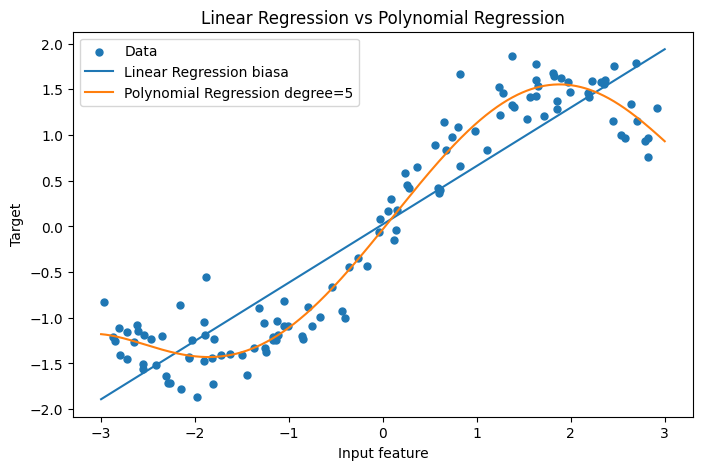

In [67]:
poly_model = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("linear", LinearRegression())
])

poly_model.fit(X_wave, y_wave)

plt.figure(figsize=(8, 5))
plt.scatter(X_wave[:, 0], y_wave, s=25, label="Data")
plt.plot(line[:, 0], lin_reg.predict(line), label="Linear Regression biasa")
plt.plot(line[:, 0], poly_model.predict(line), label="Polynomial Regression degree=5")
plt.xlabel("Input feature")
plt.ylabel("Target")
plt.title("Linear Regression vs Polynomial Regression")
plt.legend()
plt.show()

## Analisis Polynomial Features

Polynomial features dapat meningkatkan kemampuan model linear untuk menangkap hubungan non-linear. Namun, degree yang terlalu tinggi dapat membuat model terlalu mengikuti noise pada data training.

| Aspek | Penjelasan |
|---|---|
| Keuntungan | Membuat model linear lebih fleksibel |
| Risiko | Overfitting jika degree terlalu tinggi |
| Kebutuhan preprocessing | Sering membutuhkan scaling |
| Cocok untuk | Model linear seperti Linear Regression, Ridge, dan Logistic Regression |

Model seperti Random Forest atau Gradient Boosting biasanya tidak terlalu membutuhkan polynomial features karena sudah dapat menangkap pola non-linear melalui struktur pohon.

## Studi Perbandingan: Ridge dan Random Forest

Bagian ini menunjukkan bahwa fitur tambahan seperti polynomial features tidak selalu membantu semua model. Untuk model linear seperti Ridge, fitur polinomial dapat membantu. Untuk model tree-based seperti Random Forest, manfaatnya sering lebih kecil atau bahkan dapat menurunkan performa.

In [68]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california.data
y = california.target

# Menggunakan subset agar proses cepat
X = X[:1200]
y = y[:1200]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

ridge_base = Ridge().fit(X_train_scaled, y_train)
ridge_poly = Ridge().fit(X_train_poly, y_train)

rf_base = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)
rf_poly = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_poly, y_train)

results = pd.DataFrame({
    "Model": ["Ridge", "Ridge + Polynomial", "Random Forest", "Random Forest + Polynomial"],
    "Jumlah Fitur": [X_train_scaled.shape[1], X_train_poly.shape[1], X_train_scaled.shape[1], X_train_poly.shape[1]],
    "R2 Test Score": [
        ridge_base.score(X_test_scaled, y_test),
        ridge_poly.score(X_test_poly, y_test),
        rf_base.score(X_test_scaled, y_test),
        rf_poly.score(X_test_poly, y_test)
    ]
})

results

,Model,Jumlah Fitur,R2 Test Score
0,Ridge,8,0.726228
1,Ridge + Polynomial,44,-0.931022
2,Random Forest,8,0.844599
3,Random Forest + Polynomial,44,0.834520


## Analisis Perbandingan Model

Tabel hasil eksperimen memperlihatkan bahwa penambahan polynomial features mengubah jumlah fitur secara signifikan. Pada model linear, penambahan fitur ini dapat membantu karena model memperoleh representasi yang lebih kaya. Namun, pada Random Forest, fitur tambahan tidak selalu memberikan peningkatan karena model sudah memiliki kemampuan menangkap hubungan non-linear.

Kesimpulan penting dari bagian ini adalah bahwa feature engineering harus disesuaikan dengan jenis model. Tidak ada transformasi fitur yang selalu terbaik untuk semua algoritma.

| Jenis Model | Biasanya Membutuhkan Feature Engineering? | Contoh Transformasi yang Sering Berguna |
|---|---|---|
| Linear Model | Ya | Scaling, one-hot encoding, binning, polynomial |
| Tree-Based Model | Lebih sedikit | Encoding kategorikal, handling missing values |
| Neural Network | Ya | Scaling, encoding, normalisasi distribusi |
| SVM | Ya | Scaling, transformasi fitur |

## Nonlinear Transformations

Nonlinear transformations digunakan untuk mengubah distribusi fitur. Contoh transformasi yang umum adalah `log`, `exp`, dan `sqrt`.

Transformasi log sering digunakan pada data hitungan atau data yang distribusinya sangat miring ke kanan. Misalnya, jumlah kunjungan pengguna, jumlah transaksi, atau jumlah klik. Data seperti ini biasanya memiliki banyak nilai kecil dan sedikit nilai yang sangat besar.

| Transformasi | Kegunaan |
|---|---|
| Log | Mengurangi pengaruh nilai ekstrem |
| Square root | Alternatif untuk data hitungan |
| Exp | Mengembalikan skala log atau memperbesar perbedaan |
| Sin/Cos | Cocok untuk data periodik seperti jam, bulan, atau hari |

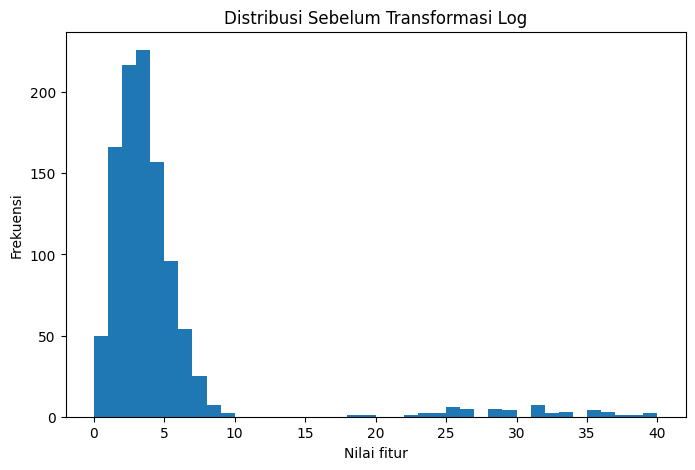

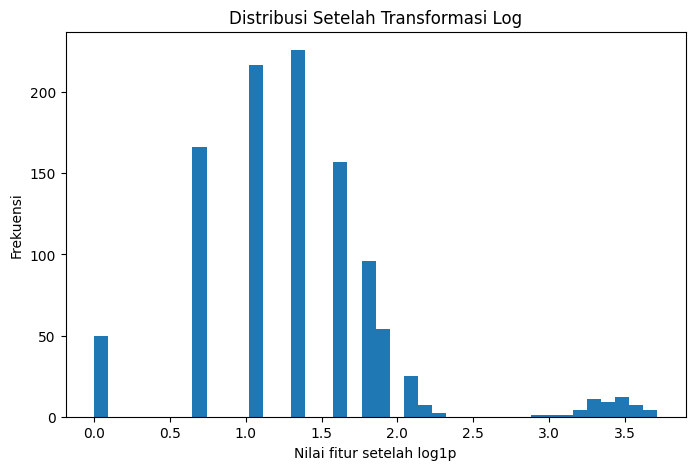

In [69]:
rng = np.random.RandomState(42)

count_data = rng.poisson(lam=3, size=1000)
count_data = np.concatenate([count_data, rng.poisson(lam=30, size=50)])

log_count_data = np.log1p(count_data)

plt.figure(figsize=(8, 5))
plt.hist(count_data, bins=40)
plt.xlabel("Nilai fitur")
plt.ylabel("Frekuensi")
plt.title("Distribusi Sebelum Transformasi Log")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(log_count_data, bins=40)
plt.xlabel("Nilai fitur setelah log1p")
plt.ylabel("Frekuensi")
plt.title("Distribusi Setelah Transformasi Log")
plt.show()

## Analisis Transformasi Log

Sebelum transformasi, data memiliki distribusi yang sangat miring. Sebagian besar nilai berada di rentang kecil, sementara beberapa nilai jauh lebih besar. Kondisi ini dapat menyulitkan model linear atau neural network karena skala fitur menjadi tidak seimbang.

Setelah menggunakan `log1p`, nilai ekstrem menjadi lebih kecil pengaruhnya dan distribusi menjadi lebih mudah dipelajari. Fungsi `log1p(x)` digunakan karena aman untuk nilai nol, yaitu setara dengan `log(1 + x)`.

## Ringkasan Metode Feature Engineering

Tabel berikut merangkum metode utama yang dibahas pada chapter ini.

| Metode | Tipe Data | Tujuan | Cocok untuk Model |
|---|---|---|---|
| One-Hot Encoding | Kategorikal | Mengubah kategori menjadi numerik | Hampir semua model |
| Numeric Category Encoding | Kategori berkode angka | Mencegah makna angka yang salah | Linear model, SVM, neural network |
| Binning | Kontinu | Membagi nilai menjadi interval | Linear model |
| Interaction Features | Numerik/kategorikal hasil encoding | Menangkap hubungan antarfitur | Linear model |
| Polynomial Features | Numerik | Membentuk pola non-linear | Linear model, Ridge, Lasso |
| Log Transformation | Numerik skewed | Mengurangi pengaruh outlier dan skewness | Linear model, neural network |

## Kesalahan Umum dalam Feature Engineering

Beberapa kesalahan yang sering terjadi dalam feature engineering adalah:

| Kesalahan | Dampak |
|---|---|
| Menganggap semua angka sebagai fitur kontinu | Model salah memahami kategori berkode angka |
| Melakukan encoding train dan test secara terpisah | Kolom hasil encoding dapat berbeda |
| Memasukkan target ke dalam fitur | Terjadi data leakage |
| Membuat terlalu banyak fitur baru | Risiko overfitting meningkat |
| Tidak melakukan scaling pada model yang sensitif skala | Model dapat memiliki performa buruk |
| Menggunakan transformasi tanpa memahami data | Transformasi bisa tidak berguna atau merusak informasi |

## Kesimpulan Chapter

Chapter ini menekankan bahwa representasi data merupakan bagian penting dalam machine learning. Algoritma yang kuat tidak akan bekerja optimal apabila fitur yang diberikan tidak sesuai. Feature engineering membantu mengubah data menjadi bentuk yang lebih informatif, baik melalui encoding kategori, binning, interaction features, polynomial features, maupun nonlinear transformations.

Dari pembahasan dan eksperimen dalam notebook ini, dapat disimpulkan bahwa:

- Data kategorikal perlu diubah menjadi numerik sebelum digunakan oleh banyak model.
- One-hot encoding efektif untuk kategori tanpa urutan alami.
- Angka tidak selalu berarti nilai kontinu; angka dapat menjadi label kategori.
- Binning dapat membantu model linear menangkap pola non-linear.
- Interaction features membantu model memahami hubungan antarvariabel.
- Polynomial features membuat model linear lebih fleksibel, tetapi dapat menyebabkan overfitting jika berlebihan.
- Transformasi log berguna untuk data yang sangat skewed.
- Setiap teknik feature engineering harus dipilih berdasarkan jenis data dan jenis model yang digunakan.

Dengan demikian, feature engineering bukan sekadar tahap tambahan, tetapi merupakan salah satu komponen utama dalam membangun model machine learning yang baik.